<a href="https://colab.research.google.com/github/Samhithagit/Samhitha_A_1BM23CS293_ML_LAB/blob/main/1BM23CS293_Lab_5_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("iris (1).csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Choose k value
k = 5

# Build model
model = KNeighborsClassifier(n_neighbors=k)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[11  0  0]
 [ 0 10  0]
 [ 0  0  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00         9

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [7]:
import pandas as pd
import numpy as np
from collections import Counter

# Load dataset
data = pd.read_csv("iris (1).csv")

# Shuffle data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Train Test Split (80-20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Euclidean Distance
def distance(a, b):
    return np.sqrt(np.sum((a-b)**2))

# KNN
def knn_predict(X_train, y_train, x, k):
    dist = []
    for i in range(len(X_train)):
        d = distance(X_train[i], x)
        dist.append((d, y_train[i]))

    dist.sort()
    neighbors = [dist[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

k = 5
predictions = []

for x in X_test:
    predictions.append(knn_predict(X_train, y_train, x, k))

# Accuracy
correct = sum(predictions[i] == y_test[i] for i in range(len(y_test)))
accuracy = correct / len(y_test)
print("Accuracy:", accuracy)

# Confusion Matrix
labels = list(set(y))
n = len(labels)

matrix = np.zeros((n,n))

for i in range(len(y_test)):
    r = labels.index(y_test[i])
    c = labels.index(predictions[i])
    matrix[r][c] += 1

print("\nConfusion Matrix:")
print(matrix)

# Classification Report
print("\nClassification Report")

for i in range(n):

    TP = matrix[i][i]
    FP = sum(matrix[:,i]) - TP
    FN = sum(matrix[i,:]) - TP

    precision = TP/(TP+FP) if (TP+FP)!=0 else 0
    recall = TP/(TP+FN) if (TP+FN)!=0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)!=0 else 0

    print(labels[i])
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1-score:",f1)
    print()

Accuracy: 0.9666666666666667

Confusion Matrix:
[[ 7.  0.  0.]
 [ 0. 11.  1.]
 [ 0.  0. 11.]]

Classification Report
setosa
Precision: 1.0
Recall: 1.0
F1-score: 1.0

virginica
Precision: 1.0
Recall: 0.9166666666666666
F1-score: 0.9565217391304348

versicolor
Precision: 0.9166666666666666
Recall: 1.0
F1-score: 0.9565217391304348



In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("diabetes.csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Choose k
k = 5

# Train model
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6948051948051948
Confusion Matrix:
[[79 20]
 [27 28]]


In [11]:
import pandas as pd
import numpy as np
from collections import Counter

# Load dataset
data = pd.read_csv("diabetes.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Shuffle dataset
index = np.random.permutation(len(X))
X = X[index]
y = y[index]

# Train Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -------- Feature Scaling (Standardization) --------
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# -------- Distance Function --------
def distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# -------- KNN Function --------
def knn_predict(X_train, y_train, x, k):
    distances = []

    for i in range(len(X_train)):
        d = distance(X_train[i], x)
        distances.append((d, y_train[i]))

    distances.sort()
    neighbors = [distances[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

k = 5
predictions = []

for x in X_test:
    predictions.append(knn_predict(X_train, y_train, x, k))

# -------- Accuracy --------
correct = sum(predictions[i] == y_test[i] for i in range(len(y_test)))
accuracy = correct / len(y_test)

print("Accuracy:", accuracy)

# -------- Confusion Matrix --------
matrix = np.zeros((2,2))

for i in range(len(y_test)):
    matrix[int(y_test[i])][int(predictions[i])] += 1

print("Confusion Matrix:")
print(matrix)

Accuracy: 0.7142857142857143
Confusion Matrix:
[[81. 13.]
 [31. 29.]]


Best K: 7
Best Accuracy: 0.9180327868852459
Confusion Matrix:
[[27  2]
 [ 3 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



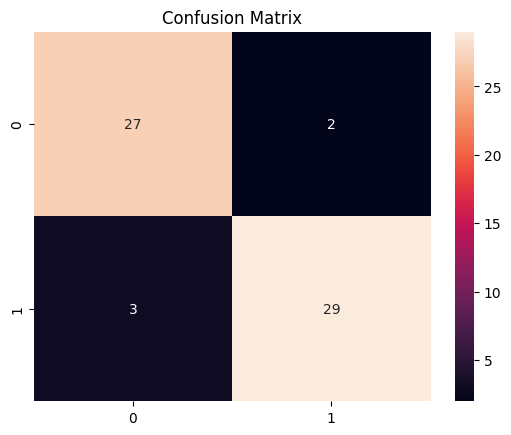

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("heart.csv")

# Features and target
X = data.drop("target", axis=1)
y = data["target"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Find best K
best_k = 1
best_score = 0

for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    score = accuracy_score(y_test,y_pred)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:",best_k)
print("Best Accuracy:",best_score)

# Train model with best K
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

# Plot Confusion Matrix
sns.heatmap(cm,annot=True)
plt.title("Confusion Matrix")
plt.show()

Best K: 13
Accuracy: 0.8524590163934426

Confusion Matrix
[[26.  5.]
 [ 4. 26.]]

Classification Report
Class 0
Precision: 0.8666666666666667
Recall: 0.8387096774193549
F1-score: 0.8524590163934426

Class 1
Precision: 0.8387096774193549
Recall: 0.8666666666666667
F1-score: 0.8524590163934426



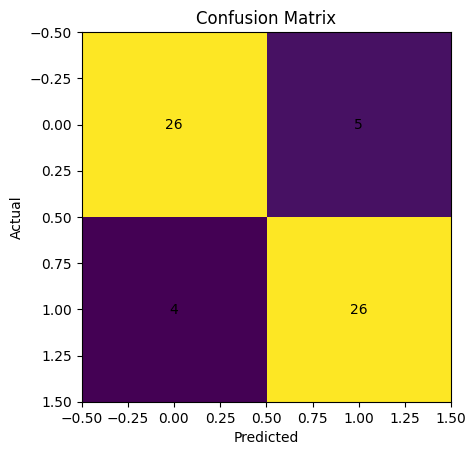

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Load dataset
data = pd.read_csv("heart.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Shuffle data
index = np.random.permutation(len(X))
X = X[index]
y = y[index]

# Train test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Feature scaling
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Euclidean distance
def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

# KNN prediction
def knn(X_train,y_train,x,k):
    dist=[]

    for i in range(len(X_train)):
        d=distance(X_train[i],x)
        dist.append((d,y_train[i]))

    dist.sort()

    neighbors=[dist[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

# Find best K
best_k=1
best_acc=0

for k in range(1,21):

    pred=[]

    for x in X_test:
        pred.append(knn(X_train,y_train,x,k))

    acc=sum(pred[i]==y_test[i] for i in range(len(y_test)))/len(y_test)

    if acc>best_acc:
        best_acc=acc
        best_k=k

print("Best K:",best_k)
print("Accuracy:",best_acc)

# Final prediction
pred=[]

for x in X_test:
    pred.append(knn(X_train,y_train,x,best_k))

# Confusion Matrix
matrix=np.zeros((2,2))

for i in range(len(y_test)):
    matrix[int(y_test[i])][int(pred[i])] +=1

print("\nConfusion Matrix")
print(matrix)

# -------- Classification Report --------
print("\nClassification Report")

for i in range(2):

    TP = matrix[i][i]
    FP = sum(matrix[:,i]) - TP
    FN = sum(matrix[i,:]) - TP

    precision = TP/(TP+FP) if (TP+FP)!=0 else 0
    recall = TP/(TP+FN) if (TP+FN)!=0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)!=0 else 0

    print("Class",i)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1-score:",f1)
    print()

# -------- Plot Confusion Matrix --------
plt.imshow(matrix)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j,i,int(matrix[i][j]),ha='center',va='center')

plt.show()